# ACT Training on comma2k19

git clone https://github.com/Arivoli-A/comma2k19_FSD.git -b Arivoli

In [1]:
# !pip install lerobot
from pathlib import Path

PROJECT_DIR = Path.cwd()
CHUNK_PATH = PROJECT_DIR / "comma2k19_data" / "extracted" / "Chunk_1"
DATASET_REPO_ID = "local/comma2k19_act"
DATASET_ROOT = PROJECT_DIR / "lerobot_datasets" / DATASET_REPO_ID
OUTPUT_DIR = PROJECT_DIR / "outputs" / "train" / "act_comma2k19"

print("Project:", PROJECT_DIR)
print("Chunk:", CHUNK_PATH)
print("Dataset root:", DATASET_ROOT)
print("Output:", OUTPUT_DIR)

Project: /teamspace/studios/this_studio
Chunk: /teamspace/studios/this_studio/comma2k19_data/extracted/Chunk_1
Dataset root: /teamspace/studios/this_studio/lerobot_datasets/local/comma2k19_act
Output: /teamspace/studios/this_studio/outputs/train/act_comma2k19


In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path(".").resolve()))

from types import SimpleNamespace

import torch
import matplotlib.pyplot as plt
import numpy as np

import comma2k19_FSD.act_training as act_training

In [3]:
args = SimpleNamespace(

    # --- paths ---
    base_dir=Path("."),
    dataset_root=Path("./lerobot_datasets"),
    repo_id="local/comma2k19_act",
    output_dir=Path("./outputs/train/act_comma2k19"),
    project_scripts_dir=Path("./comma2k19_FSD"),

    # --- chunks ---
    chunks=[1],
    hf_token=None,

    # --- conversion ---
    width=256,
    height=256,
    fps=20,
    future_time=1.0,
    max_episodes=50,
    max_frames=None,

    # --- windowing ---
    obs_horizon=4,
    action_horizon=10,
    pred_horizon=10,

    # --- training ---
    device="cuda",
    batch_size=8,
    steps=10000,
    num_workers=4,
    val_fraction=0.1,
    log_every=100,
    save_every=1000,
    seed=42,

    # --- inference ---
    checkpoint=None,
    inference_episodes=3,

    # --- skip flags ---
    skip_download=False,
    skip_extract=False,
    skip_convert=False,
    skip_train=False,
)

# Load Dataset

In [7]:
act_training.stage_download_extract(args)


  Stage 1 — Chunk 1: download + extract


Chunk        : 1
Base dir     : /teamspace/studios/this_studio
Zip path     : raw_data/Chunk_1.zip
Extract path : extracted/Chunk_1

Downloaded: raw_data/Chunk_1.zip  (8.13 GB)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Found 7333 files in Chunk_1.zip. Extracting ...


Extracting: 100%|██████████| 7333/7333 [00:56<00:00, 129.45it/s]


...

  1181 frames  (55879 total)
[49/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-31--20-50-28/6


Map: 100%|██████████| 1181/1181 [00:00<00:00, 2038.90 examples/s]
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 3
Svt[info]: Number of PPCS 42
Svt[info]: [asm level on system : up to avx512]
Svt[info]: [asm level selected : up to avx512]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 256 / 256 / 20 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / k

  1181 frames  (57060 total)
[50/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-31--20-50-28/7


Map: 100%|██████████| 1181/1181 [00:00<00:00, 2076.42 examples/s]
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 3
Svt[info]: Number of PPCS 42
Svt[info]: [asm level on system : up to avx512]
Svt[info]: [asm level selected : up to avx512]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 256 / 256 / 20 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / k

  1181 frames  (58241 total)

Done.   Dataset : lerobot_datasets/local/comma2k19_act
        Repo id : local/comma2k19_act
       Episodes : 50
         Frames : 58241

Loading LeRobotDataset with windowing:
  obs_horizon   : 1  offsets: [-0.0]
  pred_horizon  : 16  offsets: [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
  action_horizon: 16  (first 16 of pred window used)
  Total frames  : 58241
  Episodes      : 50
LeRobotDataset({
    Repository ID: 'local/comma2k19_act',
    Number of selected episodes: '50',
    Number of selected samples: '58241',
    Features: '['observation.images.front', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
{'observation.images.front': {'dtype': 'video', 'shape': (256, 256, 3), 'names': ['height', 'width', 'channel'], 'info': {'video.height': 256, 'video.width': 256, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'video.f

In [5]:
act_training.stage_convert(args)


  Stage 2 — Chunk 1: convert to LeRobot
Found 188 segments.
State : [speed_mps, steer_deg] at t          shape (2,)
Action: [speed_mps, steer_deg] at t + 1.0s  shape (2,)

[1/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-27--06-03-57/3


Map: 100%|██████████| 1179/1179 [00:01<00:00, 890.62 examples/s]


  1179 frames  (1179 total)
[2/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-27--06-03-57/4


Map: 100%|██████████| 1179/1179 [00:02<00:00, 531.76 examples/s]


  1179 frames  (2358 total)
[3/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-27--06-03-57/5


...

  1181 frames  (55879 total)
[49/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-31--20-50-28/6


Map: 100%|██████████| 1181/1181 [00:02<00:00, 581.95 examples/s]


  1181 frames  (57060 total)
[50/188] extracted/Chunk_1/b0c9d2329ad1606b_2018-07-31--20-50-28/7


Map: 100%|██████████| 1181/1181 [00:02<00:00, 579.13 examples/s]


  1181 frames  (58241 total)

Done.   Dataset : lerobot_datasets/local/comma2k19_act
        Repo id : local/comma2k19_act
       Episodes : 50
         Frames : 58241


In [4]:
dataset = act_training.load_lerobot_dataset(args)

print(dataset)
print(dataset.features)


Loading LeRobotDataset with windowing:
  obs_horizon   : 4  offsets: [-0.15, -0.1, -0.05, -0.0]
  pred_horizon  : 10  offsets: [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
  action_horizon: 10  (first 10 of pred window used)
  Total frames  : 58241
  Episodes      : 50
LeRobotDataset({
    Repository ID: 'local/comma2k19_act',
    Number of selected episodes: '50',
    Number of selected samples: '58241',
    Features: '['observation.images.front', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
{'observation.images.front': {'dtype': 'image', 'shape': (256, 256, 3), 'names': ['height', 'width', 'channel']}, 'observation.state': {'dtype': 'float32', 'shape': (2,), 'names': ['speed_mps', 'steer_deg']}, 'action': {'dtype': 'float32', 'shape': (2,), 'names': ['future_speed_mps', 'future_steer_deg']}, 'timestamp': {'dtype': 'float32', 'shape': (1,), 'names': None}, 'frame_index': {'dtype': 'int64', 'shape': (1,), 'names': N

In [5]:
sample = dataset[0]

for k, v in sample.items():
    if hasattr(v, "shape"):
        print(k, v.shape)
    else:
        print(k, type(v))

observation.images.front torch.Size([4, 3, 256, 256])
observation.state torch.Size([4, 2])
action torch.Size([10, 2])
timestamp torch.Size([])
frame_index torch.Size([])
episode_index torch.Size([])
index torch.Size([])
task_index torch.Size([])
observation.images.front_is_pad torch.Size([4])
observation.state_is_pad torch.Size([4])
action_is_pad torch.Size([10])
task <class 'str'>


# Sliding window observations and action chunk

torch.Size([4, 3, 256, 256])


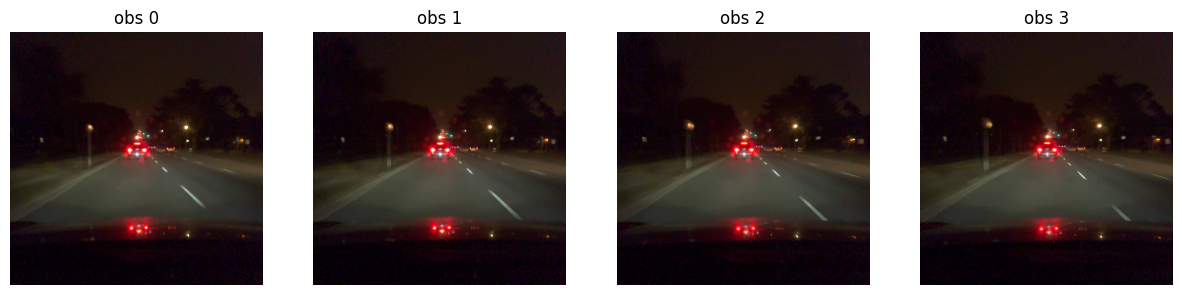

In [9]:
sample = dataset[100]

images = sample["observation.images.front"]

print(images.shape)

fig, axes = plt.subplots(1, len(images), figsize=(15, 4))

for i in range(len(images)):
    img = np.transpose(images[i], (1, 2, 0))
    axes[i].imshow(img)
    axes[i].set_title(f"obs {i}")
    axes[i].axis("off")

plt.show()

In [10]:
sample = dataset[100]

actions = sample["action"]

print(actions.shape)
print(actions)

torch.Size([10, 2])
tensor([[19.7936, -4.0281],
        [19.7677, -3.7265],
        [19.7566, -3.3525],
        [19.7187, -3.0000],
        [19.7505, -2.9761],
        [19.6788, -2.7337],
        [19.6933, -2.4758],
        [19.6003, -1.8575],
        [19.6036, -1.1701],
        [19.5098, -0.5245]])


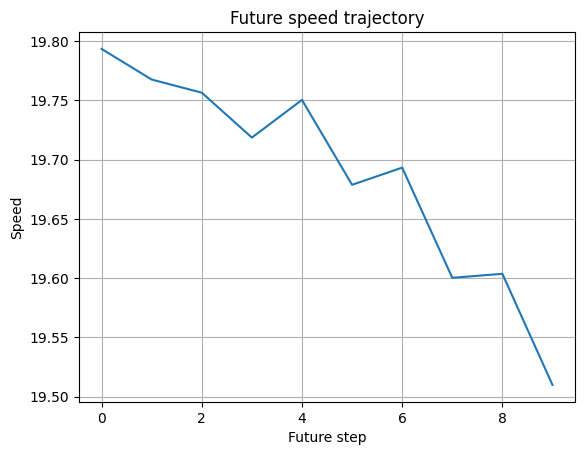

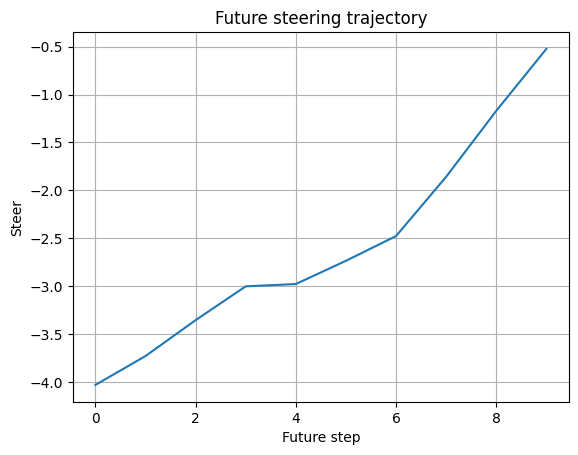

In [11]:
plt.plot(actions[:, 0])
plt.title("Future speed trajectory")
plt.xlabel("Future step")
plt.ylabel("Speed")
plt.grid()
plt.show()

plt.plot(actions[:, 1])
plt.title("Future steering trajectory")
plt.xlabel("Future step")
plt.ylabel("Steer")
plt.grid()
plt.show()

# Train/Val split

In [6]:
train_set, val_set, val_episode_ids = act_training.split_dataset(
    dataset,
    args.val_fraction,
    args.seed,
)

train_loader, val_loader = act_training.make_dataloaders(
    train_set,
    val_set,
    args,
)

print(len(train_set))
print(len(val_set))

ValueError: Column 'episode_index' doesn't exist.

# Build ACT model

In [ ]:
policy, device = act_training.make_act_policy(
    dataset,
    args,
)

print(type(policy))

In [ ]:
batch = next(iter(train_loader))

batch = {
    k: v.to(device)
    if hasattr(v, "to")
    else v
    for k, v in batch.items()
}

In [ ]:
loss, info = policy.forward(batch)

print("loss =", loss.item())

print(info)

In [ ]:
with torch.no_grad():
    out = policy.model(batch)

print(type(out))

if isinstance(out, dict):
    print(out.keys())

# Training

In [ ]:
# Train
act_training.train(
    policy,
    train_loader,
    val_loader,
    args,
    device,
)

# Evaluation

In [ ]:
ckpt_dir = Path("./outputs/train/act_comma2k19/checkpoints/last/pretrained_model")

policy = act_training.load_policy_from_checkpoint(ckpt_dir, device)
policy.eval()

In [ ]:
val_loss = act_training.evaluate(
    policy,
    val_loader,
    device,
    max_batches=50,
)

print("Validation loss:", val_loss)

## Full rollout evaluation

In [ ]:
import torch
import numpy as np

all_mae_speed = []
all_mae_steer = []

policy.eval()

with torch.no_grad():
    for batch in val_loader:

        batch = {
            k: v.to(device) if hasattr(v, "to") else v
            for k, v in batch.items()
        }

        pred = policy.select_action(batch)   # (B, H, 2)
        gt   = batch["action"]               # (B, H, 2)

        mae_speed = torch.abs(pred[..., 0] - gt[..., 0]).mean().item()
        mae_steer = torch.abs(pred[..., 1] - gt[..., 1]).mean().item()

        all_mae_speed.append(mae_speed)
        all_mae_steer.append(mae_steer)

print("Chunk MAE speed:", np.mean(all_mae_speed))
print("Chunk MAE steer:", np.mean(all_mae_steer))

## Horizon-wise error

In [ ]:
import torch
import numpy as np

H = args.action_horizon

errors_speed = np.zeros(H)
errors_steer = np.zeros(H)
counts = np.zeros(H)

policy.eval()

with torch.no_grad():
    for batch in val_loader:

        batch = {
            k: v.to(device) if hasattr(v, "to") else v
            for k, v in batch.items()
        }

        pred = policy.select_action(batch)  # (B, H, 2)
        gt   = batch["action"]              # (B, H, 2)

        for t in range(H):
            errors_speed[t] += torch.abs(pred[:, t, 0] - gt[:, t, 0]).sum().item()
            errors_steer[t] += torch.abs(pred[:, t, 1] - gt[:, t, 1]).sum().item()
            counts[t] += pred.shape[0]

errors_speed /= counts
errors_steer /= counts

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(errors_speed, label="speed MAE")
plt.plot(errors_steer, label="steer MAE")
plt.xlabel("future step")
plt.ylabel("MAE")
plt.title("Horizon-wise ACT error")
plt.legend()
plt.grid()
plt.show()

## Rollout simulation (closed-loop style)

In [ ]:
policy.eval()

ep_idx = val_episode_ids[0]

start = int(dataset.episode_data_index["from"][ep_idx])
end   = int(dataset.episode_data_index["to"][ep_idx])

errors = []

with torch.no_grad():
    for i in range(start, min(start + 200, end)):

        sample = dataset[i]

        obs = {
            "observation.images.front": sample["observation.images.front"].unsqueeze(0).to(device),
            "observation.state": sample["observation.state"].unsqueeze(0).to(device),
        }

        pred_chunk = policy.select_action(obs)[0]  # (H,2)

        pred = pred_chunk[0]
        gt   = sample["action"]

        error = torch.abs(pred - gt.to(device)).mean().item()
        errors.append(error)

print("Rollout MAE:", np.mean(errors))

## Visualize predicted trajectory vs ground truth

In [ ]:
batch = next(iter(val_loader))

batch = {
    k: v.to(device) if hasattr(v, "to") else v
    for k, v in batch.items()
}

pred = policy.select_action(batch)
gt   = batch["action"]

i = 0  # first sample in batch

plt.figure(figsize=(10,4))

plt.plot(gt[i,:,0].cpu(), label="GT speed")
plt.plot(pred[i,:,0].cpu(), label="Pred speed")
plt.legend()
plt.title("Speed trajectory")
plt.grid()
plt.show()

plt.figure(figsize=(10,4))

plt.plot(gt[i,:,1].cpu(), label="GT steer")
plt.plot(pred[i,:,1].cpu(), label="Pred steer")
plt.legend()
plt.title("Steering trajectory")
plt.grid()
plt.show()